# 📘 Week 6 - Denoising Autoencoder using MNIST

## Objective

The objective of this assignment is to build a **Denoising Autoencoder** capable of reconstructing clean handwritten digit images from noisy inputs.

### Steps Performed
- Load and preprocess the MNIST dataset
- Add Gaussian noise to create noisy images
- Build a Convolutional Denoising Autoencoder
- Train the model using noisy images as input and clean images as target
- Generate denoised images
- Compare original, noisy, and reconstructed outputs
- Analyze the model's performance

## 📌 Import Libraries

In [22]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## 📌 Load and Preprocess the Dataset

In [23]:
# Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

print("Training Images Shape:", x_train.shape)
print("Testing Images Shape:", x_test.shape)

# Normalize pixel values (0-255 --> 0-1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape for CNN
x_train = np.reshape(x_train, (-1, 28, 28, 1))
x_test = np.reshape(x_test, (-1, 28, 28, 1))

print("\nAfter Reshaping")
print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

Training Images Shape: (60000, 28, 28)
Testing Images Shape: (10000, 28, 28)

After Reshaping
Training Shape: (60000, 28, 28, 1)
Testing Shape: (10000, 28, 28, 1)


**Data Preprocessing**

The MNIST dataset was loaded and preprocessed before training.

The preprocessing steps included:

- Loading the training and testing datasets.
- Normalizing pixel values from **0–255** to **0–1** for stable training.
- Reshaping the images to **28 × 28 × 1** to make them compatible with convolutional neural network layers.

## 📌 Visualizing Original MNIST Images

The following images represent clean handwritten digits from the MNIST dataset before adding any artificial noise.

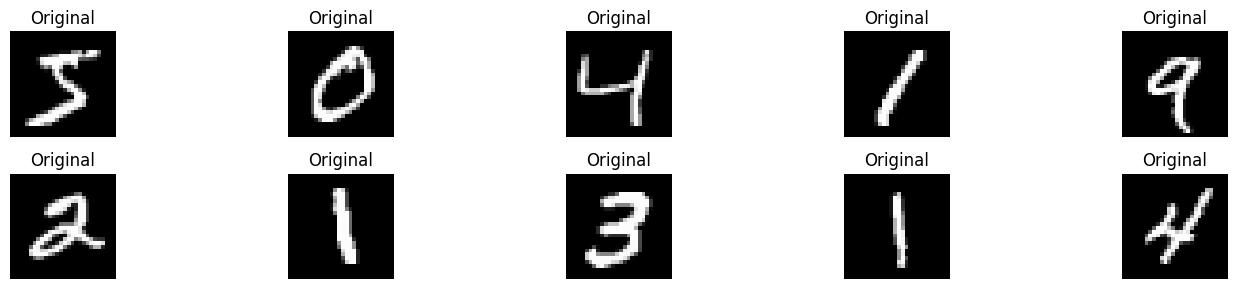

In [24]:
# Display 10 original images

plt.figure(figsize=(15,3))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 📌  Adding Gaussian Noise

Gaussian noise is artificially added to the clean MNIST images to simulate noisy inputs.

The noisy images will be used as inputs to the autoencoder, while the original clean images will serve as the target outputs during training.

In [25]:
# Add Gaussian Noise

noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Keep pixel values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noise Added Successfully!")

Noise Added Successfully!


## 📌 Visualizing Noisy Images

The following images show the effect of Gaussian noise on the original MNIST digits.

These noisy images will be used as inputs to the denoising autoencoder during training.

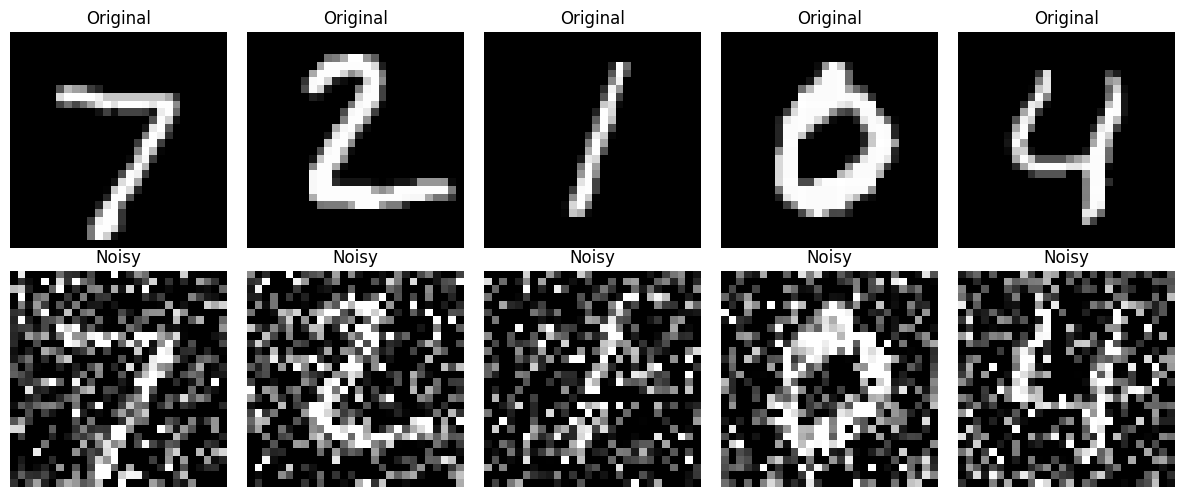

In [26]:
# Display Original vs Noisy Images

n = 5

plt.figure(figsize=(12,5))

for i in range(n):

    # Original Image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy Image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 📌 Building the Denoising Autoencoder

A **Denoising Autoencoder** is a neural network designed to reconstruct clean images from noisy inputs. It consists of two main components:

### Encoder
The encoder extracts meaningful features from the noisy input image and compresses them into a lower-dimensional latent representation (bottleneck). During this process, the spatial dimensions are reduced while important image features are preserved.

### Decoder
The decoder reconstructs the original clean image from the compressed representation by progressively restoring the spatial dimensions and recovering important visual details.

### Why Convolutional Autoencoder?

Unlike fully connected autoencoders, convolutional autoencoders preserve spatial information such as edges, curves, and local patterns, making them more suitable for image reconstruction and denoising tasks.

In [27]:
# Build Convolutional Denoising Autoencoder

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)
from tensorflow.keras.models import Model

input_img = Input(shape=(28, 28, 1))

# ===================================
# Encoder
# ===================================

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

encoded = Conv2D(128, (3,3), activation='relu', padding='same')(x)

# ===================================
# Decoder
# ===================================

x = Conv2D(128, (3,3), activation='relu', padding='same')(encoded)

x = UpSampling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)

x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)

decoded = Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

autoencoder = Model(input_img, decoded)

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

>### Model Summary Analysis

The proposed model is a **Convolutional Denoising Autoencoder** consisting of two major components: an **Encoder** and a **Decoder**. The encoder learns meaningful features from noisy images by progressively compressing the input into a compact latent representation, while the decoder reconstructs the clean image by restoring the original spatial dimensions.

#### Encoder
- Extracts important visual features such as edges, curves, and local patterns using **Conv2D** layers.
- Compresses the input image through **MaxPooling2D** layers, reducing its spatial dimensions while preserving essential information.
- Produces a compact latent representation that captures the most significant features of the image.

#### Decoder
- Reconstructs the clean image from the compressed representation.
- Uses **UpSampling2D** layers to gradually restore the original image dimensions.
- Applies **Conv2D** layers to recover important image details while suppressing noise.
- Uses **Sigmoid activation** in the output layer to produce normalized pixel values between **0 and 1**.

#### Model Characteristics
- **Input Shape:** 28 × 28 × 1
- **Output Shape:** 28 × 28 × 1
- **Hidden Layer Activation:** ReLU
- **Output Layer Activation:** Sigmoid
- **Pooling Layer:** MaxPooling2D
- **Upsampling Layer:** UpSampling2D
- **Optimizer:** Adam
- **Loss Function:** Binary Crossentropy

This architecture effectively learns compact feature representations while preserving spatial information, making it well-suited for image denoising tasks.

## 📌 Visualize the Model Architecture

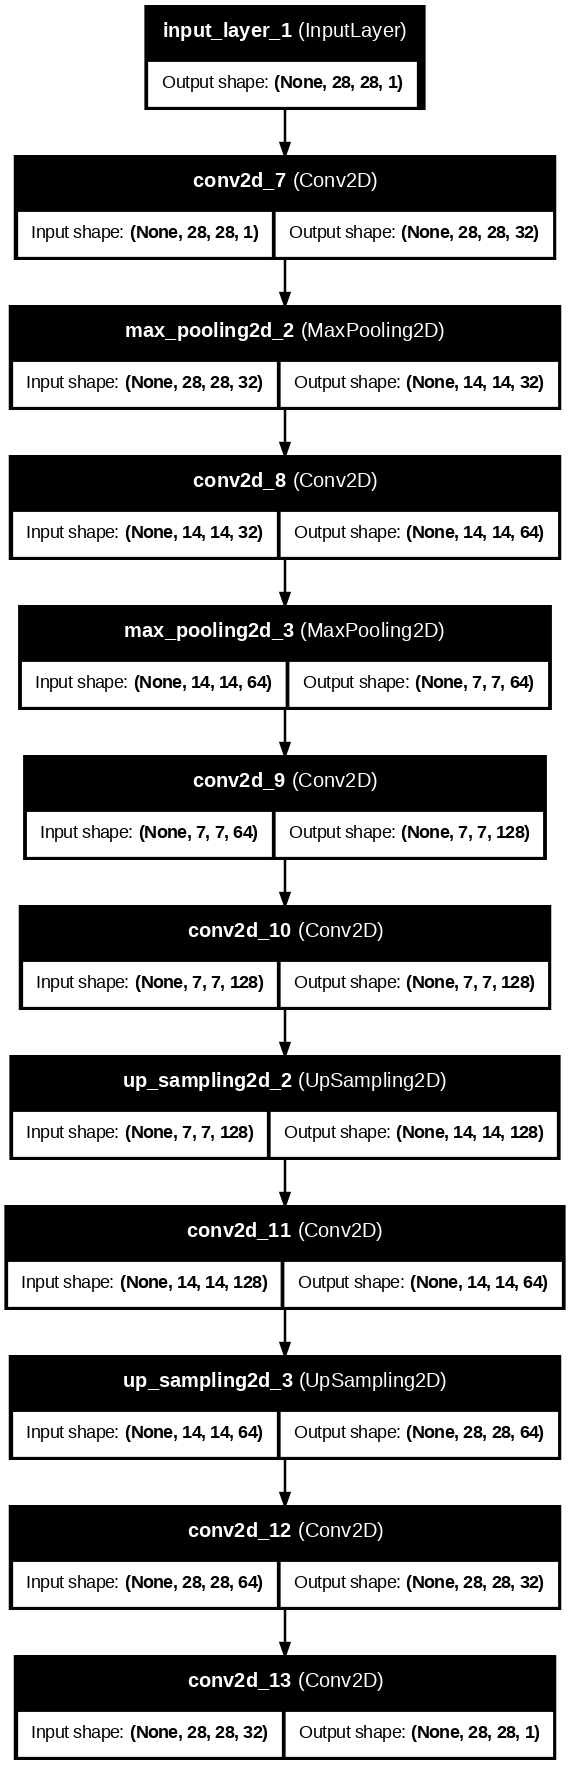

In [28]:
from tensorflow.keras.utils import plot_model

plot_model(
    autoencoder,
    show_shapes=True,
    show_layer_names=True,
    dpi=90
)

## 📌 Model Compilation

Before training, the model is compiled by specifying the optimizer and the loss function.

### Optimizer
**Adam** is used because it combines the advantages of Momentum and RMSProp, resulting in faster convergence and stable training.

### Loss Function
**Binary Crossentropy** is used as the reconstruction loss because the MNIST images are normalized to pixel values between **0 and 1**. The objective is to minimize the difference between the reconstructed image and the original clean image.

In [29]:
# Compile the Autoencoder

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

print("✅ Model compiled successfully!")

✅ Model compiled successfully!


## 📌 Model Training

The denoising autoencoder is trained using:

- **Input:** Noisy MNIST images
- **Target:** Original clean MNIST images

During training, the model learns to reconstruct clean handwritten digits by minimizing the reconstruction loss between the predicted output and the original image.

The validation dataset is used to monitor the model's performance on unseen images during training.

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stop]
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0884 - val_loss: 0.0900
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0882 - val_loss: 0.0902
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0881 - val_loss: 0.0900
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0879 - val_loss: 0.0899
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0878 - val_loss: 0.0902
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0877 - val_loss: 0.0899
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0875 - val_loss: 0.0905
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0874 - val_loss: 0.0900
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0873 - val_loss: 0.0900


>Training Performance Analysis

The graph below illustrates the variation of **training loss** and **validation loss** across epochs.

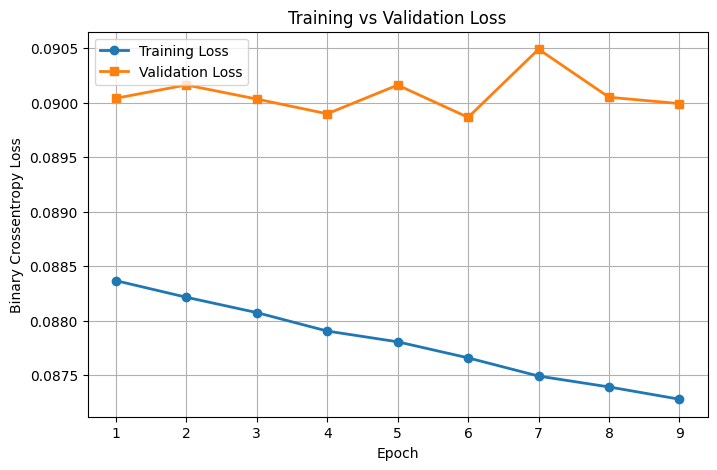

In [32]:
epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history.history['loss'],
    marker='o',
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    epochs,
    history.history['val_loss'],
    marker='s',
    linewidth=2,
    label='Validation Loss'
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.xticks(epochs)
plt.grid(True)
plt.legend()
plt.show()

## 📌  Model Evaluation

After training, the denoising autoencoder is evaluated on unseen test images.

The trained model receives noisy images as input and attempts to reconstruct their clean versions. The reconstructed images are then compared with the original and noisy images to visually assess the denoising performance.

In [33]:
# Generate Denoised Images

decoded_imgs = autoencoder.predict(x_test_noisy)

print("Denoised images generated successfully!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Denoised images generated successfully!


## 📌 Visual Comparison of Results

The figure below compares:

- **Original Image:** Clean handwritten digit.
- **Noisy Image:** Image after adding Gaussian noise.
- **Reconstructed Image:** Output generated by the trained denoising autoencoder.

A successful denoising autoencoder should remove most of the artificial noise while preserving the original digit structure.

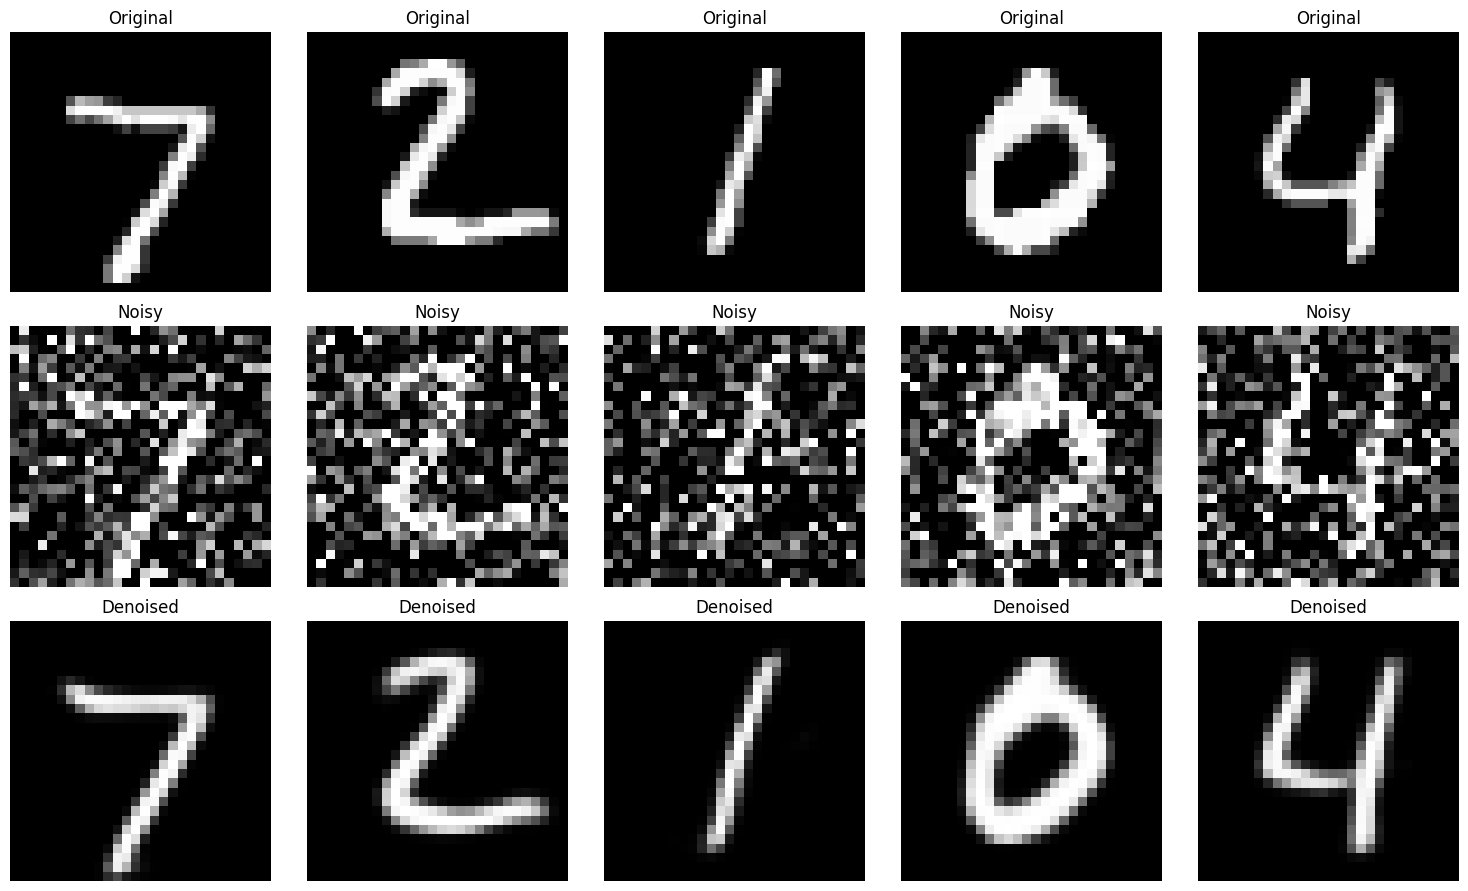

In [34]:
# Compare Original, Noisy and Denoised Images

n = 5

plt.figure(figsize=(15,9))

for i in range(n):

    # Original Image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy Image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised Image
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 📌 Reconstruction Error

To quantitatively evaluate the performance of the denoising autoencoder, the **Mean Squared Error (MSE)** between the original and reconstructed test images is calculated.

A lower MSE indicates better reconstruction quality.

In [35]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    x_test.reshape(-1),
    decoded_imgs.reshape(-1)
)

print(f"Mean Squared Error (MSE): {mse:.6f}")

Mean Squared Error (MSE): 0.009177


## 📌 Model Performance Summary

The table below summarizes the important training parameters and evaluation results of the proposed Denoising Autoencoder.

In [36]:
import pandas as pd

summary = pd.DataFrame({
    "Parameter": [
        "Dataset",
        "Model",
        "Optimizer",
        "Loss Function",
        "Epochs",
        "Batch Size",
        "Noise Type",
        "Noise Factor",
        "Input Shape",
        "Output Shape",
        "Reconstruction Error (MSE)"
    ],
    "Value": [
        "MNIST",
        "Convolutional Denoising Autoencoder",
        "Adam",
        "Binary Crossentropy",
        len(history.history['loss']),
        128,
        "Gaussian Noise",
        0.5,
        "28 × 28 × 1",
        "28 × 28 × 1",
        f"{mse:.6f}"
    ]
})

summary

,Parameter,Value
0,Dataset,MNIST
1,Model,Convolutional Denoising Autoencoder
2,Optimizer,Adam
3,Loss Function,Binary Crossentropy
4,Epochs,9
5,Batch Size,128
6,Noise Type,Gaussian Noise
7,Noise Factor,0.5
8,Input Shape,28 × 28 × 1
9,Output Shape,28 × 28 × 1


## 📌 Observations

- A Convolutional Denoising Autoencoder was successfully trained to reconstruct clean handwritten digits from noisy MNIST images.
- The model converged efficiently, with **Early Stopping terminating training after 9 epochs**, indicating that further training was unnecessary.
- The **Adam optimizer** provided stable and efficient convergence throughout the training process.
- The trained model effectively removed Gaussian noise while preserving the overall structure and shape of the handwritten digits.
- The reconstruction error (**MSE = 0.009177**) indicates that the reconstructed images were very close to the original clean images.
- Visual comparison of the original, noisy, and reconstructed images confirmed that the autoencoder successfully learned meaningful latent representations for image denoising.
- Minor smoothing was observed in some reconstructed digits, which is expected due to the compression and reconstruction process.

## 📌 Conclusion

In this assignment, a **Convolutional Denoising Autoencoder** was successfully implemented and trained using the MNIST handwritten digit dataset.

Gaussian noise with a **noise factor of 0.5** was artificially added to the images, and the model learned to reconstruct clean images from these noisy inputs. The encoder extracted compact and meaningful feature representations, while the decoder successfully restored the original image structure.

The model achieved stable convergence using the **Adam optimizer** and **Binary Crossentropy** loss. Training completed in **8 epochs** due to Early Stopping, demonstrating efficient learning without unnecessary training.

The low reconstruction error (**MSE = 0.009177**) together with the visual comparison of reconstructed images demonstrates that the proposed autoencoder effectively removed Gaussian noise while preserving important digit features.

This assignment demonstrates the practical application of convolutional autoencoders for image denoising and highlights their usefulness in image restoration, feature learning, and representation learning tasks.